In [1]:
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  
gpus = tf.config.list_physical_devices('GPU')

from utils import encode_labels, perform_random_split,  perform_patient_split, get_class_weights, plot_confusion_matrix, to_binary
import pandas as pd
df = pd.read_csv("../features-extraction/features-relative.csv")

# train_mask, test_mask, y_train, y_test = perform_patient_split(df)
train_mask, test_mask, y_train, y_test = perform_random_split(df)


drop_cols = ['Start', 'End', 'file', 'Start Sample', 'End Sample', 'Label']

X = df.drop(drop_cols, axis=1).values

X_train = X[train_mask]
X_test  = X[test_mask]

y_train, y_test, labels = encode_labels(y_train, y_test)



In [ ]:

from sklearn.ensemble import RandomForestClassifier


class_weights = get_class_weights(y_train)
rfc = RandomForestClassifier(
    random_state=0, 
    n_estimators=300, 
    # class_weight=get_class_weights(y_train)
    )

rfc.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Figure size 600x500 with 0 Axes>

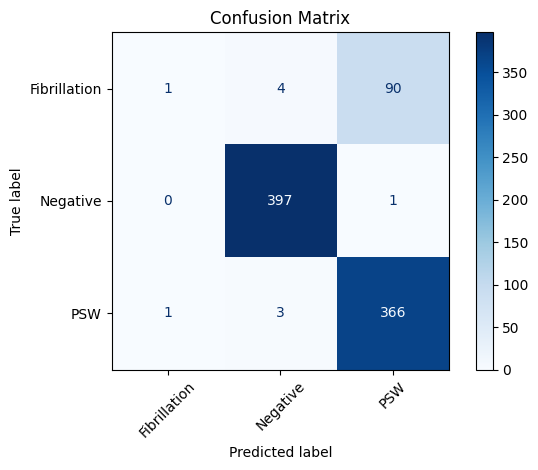


Classification Report:
              precision    recall  f1-score   support

Fibrillation       0.50      0.01      0.02        95
    Negative       0.98      1.00      0.99       398
         PSW       0.80      0.99      0.89       370

    accuracy                           0.89       863
   macro avg       0.76      0.67      0.63       863
weighted avg       0.85      0.89      0.84       863



In [3]:
y_pred = rfc.predict(X_test)

plot_confusion_matrix(y_test,y_pred, labels)

<Figure size 600x500 with 0 Axes>

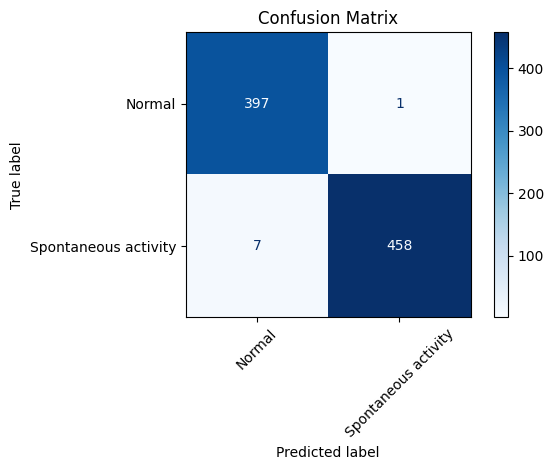


Classification Report:
                      precision    recall  f1-score   support

              Normal       0.98      1.00      0.99       398
Spontaneous activity       1.00      0.98      0.99       465

            accuracy                           0.99       863
           macro avg       0.99      0.99      0.99       863
        weighted avg       0.99      0.99      0.99       863



In [4]:
to_binary(y_test, X_test, rfc)

In [5]:

feature_scores = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(feature_scores)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

Accuracy with normal split 0.89 accuracy
with patient split 0.78